# Statistical Machine Translation Tutorial (Intro)
Ye Kyaw Thu, Lab Leader, Language Understanding Lab., Myanmar  
For AI Fundamental Class students  
Date: 26 April 2026  

ဒီ Notebook က Github က MTRSS (Machine Translation Research Summer School) က code တွေကို ဆာဗာတစ်ခုပေါ်ကို ဒေါင်းလုဒ်လုပ်ပြီး အတန်းထဲမှာ ပထမဆုံး run ပြခဲ့တာမို့ error သုံးခု တက်တာကိုလည်း လက်တွေ့ရှင်းရင်းနဲ့ run ခဲ့တဲ့ notebook ပါ။  

- ပထမ error က ထုံးစံအတိုင်းပဲ perl script တွေ၊ configuration file မှာ ကိုယ့်စက်ရဲ့ path တွေကို ဖြည့်တဲ့အခါမှာ ကျန်ခဲ့တာမျိုးပါ
- ဒုတိယ error က GIZA++ နဲ့ ပတ်သက်ပြီး ဖြစ်တဲ့ error ပါ။ GIZA++ install လုပ်ထားတဲ့ path (/home/ye/tool/giza-pp/GIZA++-v2) အောက်မှာ mklcls ဖိုင်ကိုပါ ကော်ပီကူးထည့်လိုက်ရင် ပြေလည်းပါတယ်။   
- တတိယ error ကတော့ SGM အတွက် ဆောက်ထားတဲ့ ဖိုလ်ဒါနာမည်ကို စကားပြောရင်း၊ စာသင်ရင်းနဲ့ ရိုက်လိုက်တာမို့ test-gen ဆိုပြီး မှာရိုက်လိုက်လို့ SMT run တဲ့အခါမှာ တက်တဲ့ error ပါ။ အမှန်က test-sgm ဖြစ်ရပါမယ်။ :P

## Data

In [1]:
%pwd

'/mnt/d/Job_Requirements/PracticalProjectsFromDrYe/AIE-F/assignment-submission/class-13and14/TheinGiKyaw-Assignment/SMT_Tutorial/notebook'

In [2]:
!ls ../../data/*

../../data/dev.my  ../../data/test.my  ../../data/tmp	    ../../data/train.ph
../../data/dev.ph  ../../data/test.ph  ../../data/train.my


## Data Size

for training:  

In [3]:
!wc ../../data/train.*

 20000  57336 594183 ../../data/train.my
 20000  57346 260356 ../../data/train.ph
 40000 114682 854539 total


for development or validation:  

In [4]:
!wc ../../data/dev.*

 2000  5687 59222 ../../data/dev.my
 2000  5688 25849 ../../data/dev.ph
 4000 11375 85071 total


for testing:  

In [5]:
!wc ../../data/test.*

  2802   8047  83959 ../../data/test.my
  2802   8048  36532 ../../data/test.ph
  5604  16095 120491 total


Let's see data format:  

In [6]:
!head ../../data/train.ph

pja' tha' hsaun
kou bain sa kyi. dai'
thein: do: hsa:
sa: thau' hsain
kyou: zin
hsaun kyin:
lo: ba. the' ka ja.
ga- ba:
shwei pji sou:
hai' da- rou gyin


In [7]:
!head ../../data/train.my

ပြာ သာဒ် ဆောင်
ကိုယ် ပိုင် စာ ကြည့် တိုက်
သိန် ဓော ဆား
စား သောက် ဆိုင်
ကြိုး စင်
ဆောင် ကြဉ်း
လော ဘ သက် ကာ ယ
ကမ်း ပါး
ရွှေ ပြည် စိုး
ဟိုက် ဒ ရို ဂျင်


In [8]:
!head ../../data/dev.ph

ja' mhu. jwa mhu.
pi: zei:
mjin: za: gyoun
a- ngan pei:
a- nei a- hta:
kya: mi: hswe: mi.
bo: ma.
mha' su.
ga- gywei:
mwei bwei: pou: hti.


In [9]:
!head ../../data/dev.my

ရပ် မှု ရွာ မှု
ပြီး ဆေး
မြင်း စား ဂျုံ
အ ငံ့ ပေး
အ နေ အ ထား
ကျား မြီး ဆွဲ မိ
ဘော မ
မှတ် စု
ကံ ကျွေး
မြွေ ပွေး ပိုး ထိ


In [10]:
!head ../../data/test.ph

te' te' pjaun
ka' pi.
shoun. me.
njhin: ban:
mun: man
nge mji
sha sha hpwei bwei
ba- bjin:
u. ma- kwe: thai' ma- pje'
a- si'


In [11]:
!head ../../data/test.my

တက် တက် ပြောင်
ကပ် ပိ
ရှုံ့ မဲ့
ညှဉ်း ပန်း
မွမ်း မံ
ငယ် မည်
ရှာ ရှာ ဖွေ ဖွေ
ပါး ပျဉ်း
ဥ မ ကွဲ သိုက် မ ပျက်
အ စစ်


## Data Cleaning

မနေ့ကအတန်းမှာ ရှင်းပြခဲ့သလိုပဲ။ မြန်မာစာကို sylbreak.py နဲ့ syllable breaking လုပ်တဲ့အခါမှာ စာရိုက်ထားတဲ့ အစီအစဉ် (typing order) က မမှန်တာမျိုးတွေကို တွေ့ရတယ်။ ဥပမာ "စွ န့်", "ကြ ည့်"  

အဲဒါမျိုး မဖြစ်အောင် အရင်ဆုံး မြန်မာစာ ဒေတာတွေကို cleaning လုပ်ကြရအောင်။  
မလုပ်ရင် machine translation performance ကို အနည်းနဲ့အများ သက်ရောက်မှုရှိလိမ့်မယ်။  
ပြီးတော့ ထိုင်း ကနေ မြန်မာစာကို ဘာသာပြန်ခိုင်းပြီး ထွက်လာတဲ့ output စာကြောင်းတွေမှာလည်း အမှားတွေပါနေလိမ့်မယ်။  

အရင်ဆုံး ဘယ်လိုမှားနေတယ် ဆိုတာကို မြင်သာအောင် အထက်က မှားနေတဲ့ စာလုံး နှစ်လုံးကိုပဲ သုံးပြီး အမှန် ရိုက်ထားတာနဲ့ နှိုင်းယှဉ်ကြည့်ကြရအောင်။  

text file တစ်ဖိုင်အနေနဲ့ အောက်ပါ စာကြောင်းတွေကို သိမ်းပါ။ အမှားက အပေါ်က၊ မှန်မှန်ကန်ကန် ရိုက်ထည့်ထားတာက အောက်က syllable ပါ။  

စွန့်  
စွန့်  
ကြည့်  
ကြည့်  

In [12]:
%%bash
cat <<EOF > error-eg.txt
စွန့်
စွန့်
ကြည့်
ကြည့်
EOF

ဖိုင် အဖြစ် သိမ်းမသိမ်းကို confirm လုပ်ကြည့်ပါ။  

In [13]:
!cat ./error-eg.txt

စွန့်
စွန့်
ကြည့်
ကြည့်


tool/ folder အောက်မှာ Unicode number တွေအနေနဲ့ print ထုတ်ပေးအောင် ရေးထားတဲ့ perl script ရှိတယ်။ အဲဒါကို သုံးပြီး အထက်က မြင်နေရတဲ့ မြန်မာစာ စာလုံးတွေကို ရိုက်ထုတ်ခိုင်းကြည့်ရအောင်။ အဲဒါဆိုရင် မှားတဲ့ syllable စာလုံးနဲ့ မှန်တဲ့ syllable စာလုံးအကြားမှာ typing order က ဘယ်လိုဖြစ်နေသလဲ ဆိုတာကို မြင်ရပါလိမ့်မယ်။ လေ့လာကြည့်ပါ။   

In [19]:
!perl /home/gi/tools/perl/print-codepoint.pl ./error-eg.txt

စွန့်
စ (4101, U1005) ွ (4157, U103d) န (4116, U1014) ့ (4151, U1037) ် (4154, U103a) , no. of char = 5
စွန့်
စ (4101, U1005) ွ (4157, U103d) န (4116, U1014) ် (4154, U103a) ့ (4151, U1037) , no. of char = 5
ကြည့်
က (4096, U1000) ြ (4156, U103c) ည (4106, U100a) ့ (4151, U1037) ် (4154, U103a) , no. of char = 5
ကြည့်
က (4096, U1000) ြ (4156, U103c) ည (4106, U100a) ် (4154, U103a) ့ (4151, U1037) , no. of char = 5


## Notes
အထက်မှာ မြင်ရတဲ့အတိုင်းပဲ။ ကိုယ့်ဖိုင်ထဲမှာ ရိုက်ထားတဲ့ syllable တွေရဲ့ order က မှားနေရင်တော့ sylbreak tool နဲ့ syllable segmentation လုပ်တဲ့အခါမှာ မှားဖြတ်ပေးပါလိမ့်မယ်။ pipe ကို delimiter အဖြစ်ထားပြီး ဖြတ်ရင် အောက်ပါလိုမျိုး ရလဒ် ရလိမ့်မယ်...  

In [21]:
!python /home/gi/tools/sylbreak/python/sylbreak.py --input ./error-eg.txt

စွ|န့်
စွန့်
ကြ|ည့်
ကြည့်


## Normalization  

အထက်ပါလိုမျိုး typing order အပြင်ကို တကယ်က spelling mistake, translation error စတာမျိုးတွေလည်း အများကြီး ပါနိုင်ပါတယ်။  
ဒီ tutorial မှာတော့ syllable level အမှားတွေကိုပဲ ပြင်တဲ့အပိုင်း တနည်းအားဖြင့် syllable normalization အပိုင်းကိုပဲ data cleaning ဥပမာ အနေနဲ့ လုပ်ပြပါမယ်။  

အရင်ဆုံး လက်ရှိ data folder တစ်ခုလုံးကို ကောပီကူးပြီး အဲဒီအထဲမှာပဲ normalization process ကို လုပ်ကြရအောင်။   
မဟုတ်ရင် Myanmar-Thai parallel corpus ဖိုင်တွေကို မှားပြီး ဖျက်မိတာ၊ ပြင်မိတာမျိုးတွေ ရှိရင် ပြန်ရဖို့ ခက်တာမို့။  

In [23]:
!cp -r ../../data ../../clean-data

In [24]:
!ls ../../clean-data/*

../../clean-data/dev.my   ../../clean-data/tmp
../../clean-data/test.my  ../../clean-data/train.my

../../clean-data/data:
dev.my	dev.ph	test.my  test.ph  tmp  train.my  train.ph

../../clean-data/normalize:
dev.my	      dev.ph   test.my.clean  train	train.my.clean
dev.my.clean  test.my  test.ph	      train.my	train.ph

../../clean-data/scripts:
generate_sgms.pl  src2sgm.pl	   test.my.src.sgm  test.rk.src.sgm
ref2sgm.pl	  test.my.ref.sgm  test.rk.ref.sgm


In [25]:
%cd ../../clean-data/

/mnt/d/Job_Requirements/PracticalProjectsFromDrYe/AIE-F/assignment-submission/class-13and14/TheinGiKyaw-Assignment/clean-data


/home/gi/venvs/smt-tutorial/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [26]:
%mkdir normalize

mkdir: cannot create directory ‘normalize’: File exists


In [27]:
!mv *.* ./normalize

In [28]:
!tree

.
├── data
│   ├── dev.my
│   ├── dev.ph
│   ├── test.my
│   ├── test.ph
│   ├── tmp
│   ├── train.my
│   └── train.ph
├── normalize
│   ├── dev.my
│   ├── dev.my.clean
│   ├── dev.ph
│   ├── test.my
│   ├── test.my.clean
│   ├── test.ph
│   ├── train
│   │   ├── train.my
│   │   ├── train.my.clean
│   │   └── train.ph
│   ├── train.my
│   ├── train.my.clean
│   └── train.ph
├── scripts
│   ├── generate_sgms.pl
│   ├── ref2sgm.pl
│   ├── src2sgm.pl
│   ├── test.my.ref.sgm
│   ├── test.my.src.sgm
│   ├── test.rk.ref.sgm
│   └── test.rk.src.sgm
└── tmp

4 directories, 27 files


အသစ်ဆောက်ထားတဲ့ normalize/ folder အောက်မှာပဲ မှားနေတဲ့ syllable တွေကို ပြင်တာတွေ လုပ်မယ်။ ပြီးမှ data-clean/ အောက်ကို ကော်ပီပြန်ကူးယူကြမယ်။  

Normalization tool က ဆရာတို့ Lab က develop လုပ်နေတုန်းပါပဲ။ လက်ရှိ ဗားရှင်းကိုပဲ သုံးကြရအောင်။  


In [33]:
%pwd

'/mnt/d/Job_Requirements/PracticalProjectsFromDrYe/AIE-F/assignment-submission/class-13and14/TheinGiKyaw-Assignment'

In [34]:
!ls ./syl-Normalizer/

LICENSE  README.md  ver_0.6


 **syl_normalizer.py code ကို လေ့လာကြည့်ရအောင်။**  

In [36]:
!cat ./syl-Normalizer/ver_0.6/syl_normalizer.py

"""
Burmese Syllable Normalizer

Normalizes Myanmar text using a multi-stage pipeline:

  Stage 0 – Unicode NFC normalization
  Stage 1 – Regex-based rule corrections (medial ordering, vowel fixes, etc.)
  Stage 2 – Fuzzy correction:
             (a) TargetedFuzzyCorrector – checks candidates against the
                 syllable frequency dictionary (--fuzzy-distance 1, no --ngram-lm)
             (b) NgramFuzzyCorrector    – scores candidates with an ARPA
                 n-gram language model and accepts only if the candidate is
                 strictly more probable than the original token (--ngram-lm)
  Stage 3 – Consonant+Asat merge with previous syllable
  Stage 4 – Compound syllable splitting (DP, ≤ 3 parts)

Written by Ye Kyaw Thu, LU Lab., Myanmar.
Version: 0.6

Changes from 0.5:
  * Stage 2 fuzzy correction now optionally driven by an ARPA n-gram LM
    (--ngram-lm).  Candidates are scored with Katz backoff using up to
    2 tokens of left context; a correction is accepted 

In [39]:
!ls syl-Normalizer/ver_0.6

Dataset					   ngram	  stage-1
detected_syllable_errors.txt		   notebook	  syl_normalizer.py
final_syl_dictionary_13Feb2024.sorted.txt  overview	  test.my
lm_chunks				   rebuild_lm.sh
myMono_syl_trigram.arpa			   split_lm.sh


### Algorithm of syl_normalizer

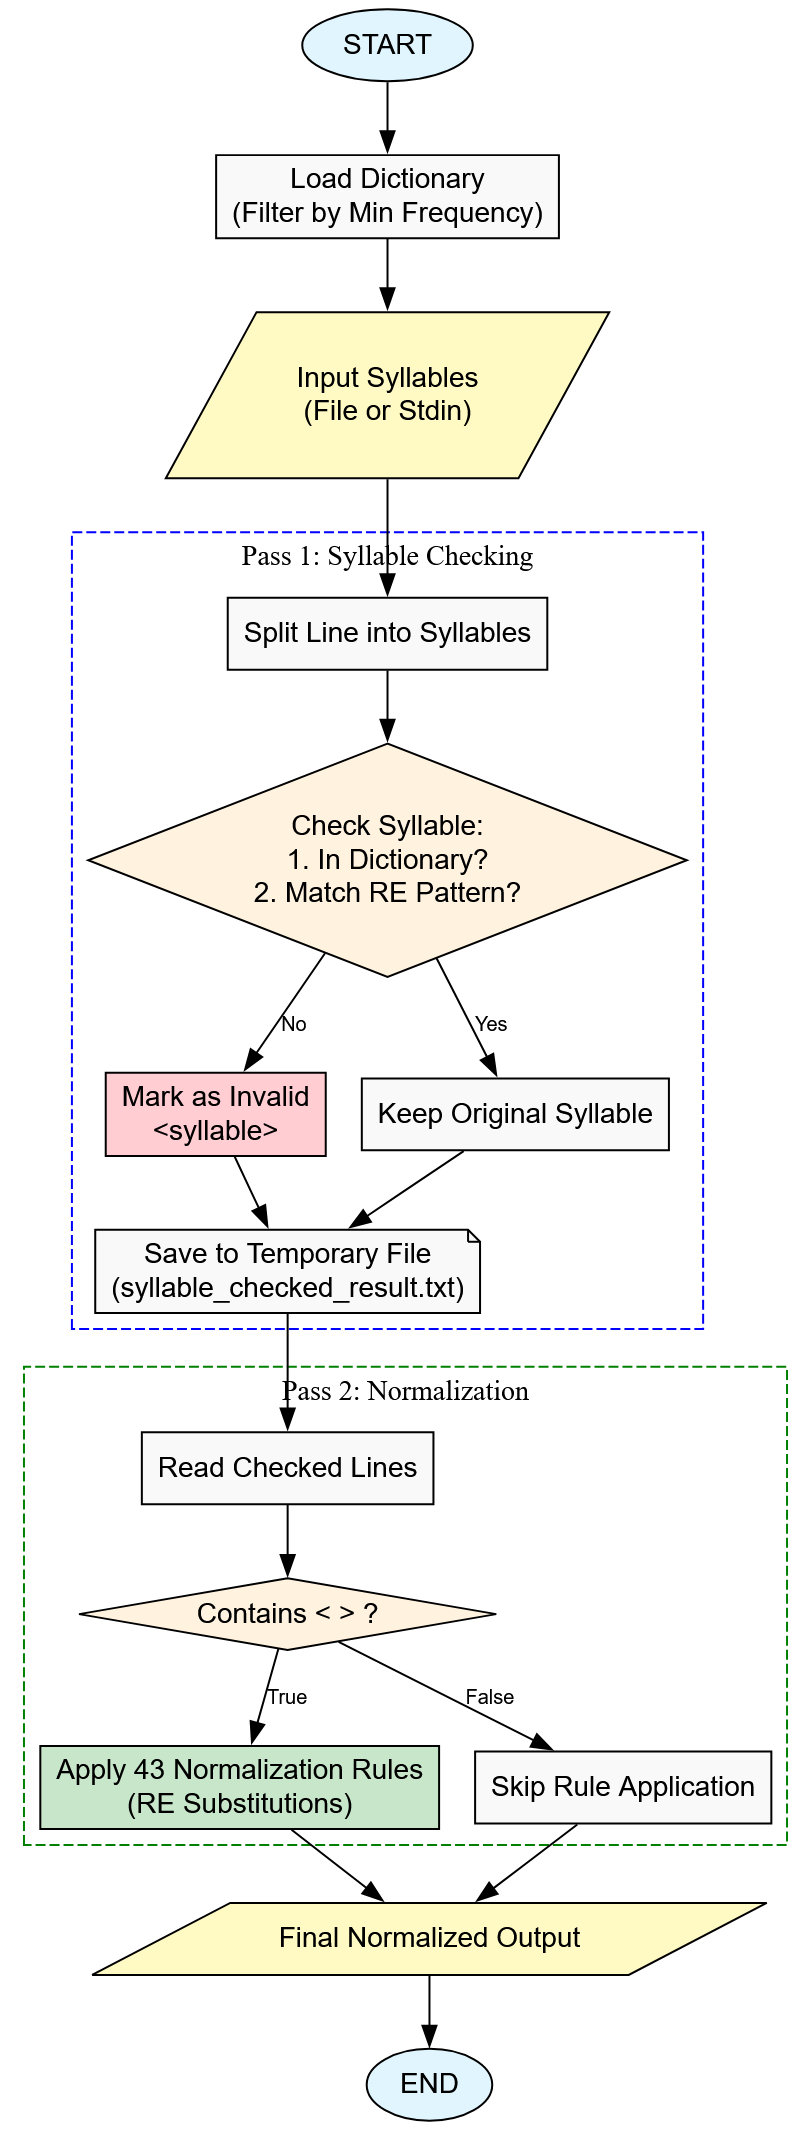

In [36]:
from IPython import display
display.Image("/home/ye/exp/SMT-NMT_tutorial/syl_normalizer/syl_normalizer.png", width=300)

အထက်က တုန်းက သုံးပြခဲ့တာက 2024 တုန်းက ဗားရှင်းပါ။ 
Notebook 2, 3 မှာက updated လုပ်ထားတဲ့ syl_normalization.py ကို သုံးထားပါတယ်။ GitHub မှာလည်း updated လုပ်ထားတဲ့ ဗားရှင်းကိုပဲ တင်ပေးထားလိုက်ပါမယ်။  
### Let's clean training, development and test dataset of Myanmar language

In [40]:
!python syl-Normalizer/ver_0.6/syl_normalizer.py --help

usage: syl_normalizer.py [-h] [--input INPUT] [--output OUTPUT] [--log LOG]
                         [--error-output ERROR_OUTPUT] [--verbose]
                         --dictionary DICTIONARY [--frequency N]
                         [--check {dictionary,RE_and_dictionary}]
                         [--fuzzy-distance N] [--ngram-lm ARPA_FILE]
                         [--min-lm-improve DELTA] [--debug-fuzzy]

Burmese Syllable Normalizer v0.6 — Normalizes Myanmar text using rules, n-gram LM fuzzy correction, consonant+asat merging, and compound splitting.

options:
  -h, --help            show this help message and exit
  --input INPUT, -i INPUT
                        Input file (space-separated syllables). Reads from
                        stdin if omitted.
  --output OUTPUT, -o OUTPUT
                        Output file with corrected text. Prints to stdout if
                        omitted.
  --log LOG, -l LOG     File to write detailed per-correction log (every rule
                

In [43]:
!python syl-Normalizer/ver_0.6/syl_normalizer.py --dictionary syl-Normalizer/ver_0.6/final_syl_dictionary_13Feb2024.sorted.txt \
--frequency 2 --input ./clean-data/normalize/train.my \
--output ./clean-data/normalize/train.my.clean 

  Fuzzy correction: disabled

=== syl_normalizer summary (v0.6) ===
  Lines processed    :     20,000
  Tokens processed   :     57,345
  Passthrough        :          6
  Already valid      :     57,244

  Fixed - stage 1 (rules, token count)    :        0
  Fixed - stage 1 (individual rule apps)  :        0

  Fixed - stage 2 ngram (dup vowel)       :        0
  Fixed - stage 2 ngram (asat removal)    :        0
  Fixed - stage 2 ngram (char sub)        :        0
  Fixed - stage 2 ngram (medial order)    :        0
  Fixed - stage 2 ngram (dup+asat)        :        0

  Fixed - stage 2 dict (dup vowel)        :        0
  Fixed - stage 2 dict (asat removal)     :        0
  Fixed - stage 2 dict (char sub)         :        0
  Fixed - stage 2 dict (medial order)     :        0
  Fixed - stage 2 dict (dup+asat)         :        0

  Fixed - stage 3 (merge with previous)   :        0
  Fixed - stage 4 (compound split)        :        0

  Total fixed        :          0
  Still unknown

In [44]:
!wc clean-data/normalize/train.my

 20000  57345 594174 clean-data/normalize/train.my


In [45]:
!wc clean-data/normalize/train.my.clean

 20000  57345 594174 clean-data/normalize/train.my.clean


In [46]:
!head clean-data/normalize/train.my.clean

ပြာ သာဒ် ဆောင်
ကိုယ် ပိုင် စာ ကြည့် တိုက်
သိန် ဓော ဆား
စား သောက် ဆိုင်
ကြိုး စင်
ဆောင် ကြဉ်း
လော ဘ သက် ကာ ယ
ကမ်း ပါး
ရွှေ ပြည် စိုး
ဟိုက် ဒ ရို ဂျင်


In [47]:
!head clean-data/normalize/train.my

ပြာ သာဒ် ဆောင်
ကိုယ် ပိုင် စာ ကြည့် တိုက်
သိန် ဓော ဆား
စား သောက် ဆိုင်
ကြိုး စင်
ဆောင် ကြဉ်း
လော ဘ သက် ကာ ယ
ကမ်း ပါး
ရွှေ ပြည် စိုး
ဟိုက် ဒ ရို ဂျင်


In [48]:
!tail clean-data/normalize/train.my.clean

စာ ညွန့်
ဒီ ချောင်း
ဝါ စာ သိ လိဋ် ဌ
ရန် ပွဲ
အ မူ ပါ
ပတ် တာ
အ မှန် စင် စစ်
ချူ ချာ
မ ဟေ သီ
လိန်း ထိုး


In [49]:
!tail clean-data/normalize/train.my

စာ ညွန့်
ဒီ ချောင်း
ဝါ စာ သိ လိဋ် ဌ
ရန် ပွဲ
အ မူ ပါ
ပတ် တာ
အ မှန် စင် စစ်
ချူ ချာ
မ ဟေ သီ
လိန်း ထိုး


**Development data cleaning ...**

In [50]:
!python syl-Normalizer/ver_0.6/syl_normalizer.py --dictionary syl-Normalizer/ver_0.6/final_syl_dictionary_13Feb2024.sorted.txt \
--frequency 2 --input clean-data/normalize/dev.my \
--output clean-data/normalize/dev.my.clean

  Fuzzy correction: disabled

=== syl_normalizer summary (v0.6) ===
  Lines processed    :      2,000
  Tokens processed   :      5,687
  Passthrough        :          0
  Already valid      :      5,676

  Fixed - stage 1 (rules, token count)    :        0
  Fixed - stage 1 (individual rule apps)  :        0

  Fixed - stage 2 ngram (dup vowel)       :        0
  Fixed - stage 2 ngram (asat removal)    :        0
  Fixed - stage 2 ngram (char sub)        :        0
  Fixed - stage 2 ngram (medial order)    :        0
  Fixed - stage 2 ngram (dup+asat)        :        0

  Fixed - stage 2 dict (dup vowel)        :        0
  Fixed - stage 2 dict (asat removal)     :        0
  Fixed - stage 2 dict (char sub)         :        0
  Fixed - stage 2 dict (medial order)     :        0
  Fixed - stage 2 dict (dup+asat)         :        0

  Fixed - stage 3 (merge with previous)   :        0
  Fixed - stage 4 (compound split)        :        0

  Total fixed        :          0
  Still unknown

In [51]:
!wc clean-data/normalize/dev.my

 2000  5687 59210 clean-data/normalize/dev.my


In [52]:
!wc clean-data/normalize/dev.my.clean

 2000  5687 59210 clean-data/normalize/dev.my.clean


**Test data cleaning ...**

In [53]:
!python syl-Normalizer/ver_0.6/syl_normalizer.py --dictionary syl-Normalizer/ver_0.6/final_syl_dictionary_13Feb2024.sorted.txt \
--frequency 2 --input clean-data/normalize/test.my \
--output clean-data/normalize/test.my.clean

  Fuzzy correction: disabled

=== syl_normalizer summary (v0.6) ===
  Lines processed    :      2,802
  Tokens processed   :      8,048
  Passthrough        :          2
  Already valid      :      8,027

  Fixed - stage 1 (rules, token count)    :        0
  Fixed - stage 1 (individual rule apps)  :        0

  Fixed - stage 2 ngram (dup vowel)       :        0
  Fixed - stage 2 ngram (asat removal)    :        0
  Fixed - stage 2 ngram (char sub)        :        0
  Fixed - stage 2 ngram (medial order)    :        0
  Fixed - stage 2 ngram (dup+asat)        :        0

  Fixed - stage 2 dict (dup vowel)        :        0
  Fixed - stage 2 dict (asat removal)     :        0
  Fixed - stage 2 dict (char sub)         :        0
  Fixed - stage 2 dict (medial order)     :        0
  Fixed - stage 2 dict (dup+asat)         :        0

  Fixed - stage 3 (merge with previous)   :        0
  Fixed - stage 4 (compound split)        :        0

  Total fixed        :          0
  Still unknown

In [54]:
!wc clean-data/normalize/test.my

 2802  8048 83945 clean-data/normalize/test.my


In [55]:
!wc clean-data/normalize/test.my.clean

 2802  8048 83945 clean-data/normalize/test.my.clean


In [56]:
%cd clean-data/normalize/

/mnt/d/Job_Requirements/PracticalProjectsFromDrYe/AIE-F/assignment-submission/class-13and14/TheinGiKyaw-Assignment/clean-data/normalize


In [57]:
!head ./test.my

တက် တက် ပြောင်
ကပ် ပိ
ရှုံ့ မဲ့
ညှဉ်း ပန်း
မွမ်း မံ
ငယ် မည်
ရှာ ရှာ ဖွေ ဖွေ
ပါး ပျဉ်း
ဥ မ ကွဲ သိုက် မ ပျက်
အ စစ်


In [58]:
!head ./test.my.clean

တက် တက် ပြောင်
ကပ် ပိ
ရှုံ့ မဲ့
ညှဉ်း ပန်း
မွမ်း မံ
ငယ် မည်
ရှာ ရှာ ဖွေ ဖွေ
ပါး ပျဉ်း
ဥ မ ကွဲ သိုက် မ ပျက်
အ စစ်


**cleaning လုပ်ထားတဲ့ ဖိုင်တွေကို machine translation လုပ်တဲ့အခါမှာ သုံးဖို့အတွက် ကော်ပီကူး ပြင်ထားကြရအောင်**

In [59]:
%pwd

'/mnt/d/Job_Requirements/PracticalProjectsFromDrYe/AIE-F/assignment-submission/class-13and14/TheinGiKyaw-Assignment/clean-data/normalize'

In [62]:
%cd ../../clean-data/

/mnt/d/Job_Requirements/PracticalProjectsFromDrYe/AIE-F/assignment-submission/class-13and14/TheinGiKyaw-Assignment/clean-data


In [63]:
!cp ./normalize/*.clean .

In [64]:
!tree .

.
├── data
│   ├── dev.my
│   ├── dev.ph
│   ├── test.my
│   ├── test.ph
│   ├── tmp
│   ├── train.my
│   └── train.ph
├── dev.my.clean
├── normalize
│   ├── dev.my
│   ├── dev.my.clean
│   ├── dev.ph
│   ├── test.my
│   ├── test.my.clean
│   ├── test.ph
│   ├── train
│   │   ├── train.my
│   │   ├── train.my.clean
│   │   └── train.ph
│   ├── train.my
│   ├── train.my.clean
│   └── train.ph
├── scripts
│   ├── generate_sgms.pl
│   ├── ref2sgm.pl
│   ├── src2sgm.pl
│   ├── test.my.ref.sgm
│   ├── test.my.src.sgm
│   ├── test.rk.ref.sgm
│   └── test.rk.src.sgm
├── test.my.clean
├── tmp
└── train.my.clean

4 directories, 30 files


**.clean တွေကို ဖြုတ်ကြရအောင်**  
SMT မှာက နောက်ဆုံး ဖိုင်နာမည်နောက်ဆုံးပိုင်း (i.e. file extension) က source/target ဘာသာစကားတွေအဖြစ် ယူဆပြီး အလုပ်လုပ်မှာမို့လို့။  

In [65]:
!mv train.my.clean train.my

In [66]:
!mv dev.my.clean dev.my

In [67]:
!mv test.my.clean test.my

In [68]:
!tree .

.
├── data
│   ├── dev.my
│   ├── dev.ph
│   ├── test.my
│   ├── test.ph
│   ├── tmp
│   ├── train.my
│   └── train.ph
├── dev.my
├── normalize
│   ├── dev.my
│   ├── dev.my.clean
│   ├── dev.ph
│   ├── test.my
│   ├── test.my.clean
│   ├── test.ph
│   ├── train
│   │   ├── train.my
│   │   ├── train.my.clean
│   │   └── train.ph
│   ├── train.my
│   ├── train.my.clean
│   └── train.ph
├── scripts
│   ├── generate_sgms.pl
│   ├── ref2sgm.pl
│   ├── src2sgm.pl
│   ├── test.my.ref.sgm
│   ├── test.my.src.sgm
│   ├── test.rk.ref.sgm
│   └── test.rk.src.sgm
├── test.my
├── tmp
└── train.my

4 directories, 30 files


## Moses SMT Framework

အောက်ပါ လင့်တွေကနေ လေ့လာပါ။ ထဲထဲဝင်ဝင် သိချင်ရင်တော့ user manual မှာ လက်တွေ့ ဘယ်လို run ရမယ် ဆိုတာ အသေးစိတ် ရေးထားတာမို့ ဖတ်ရှုလေ့လာကြပါ။ SMT ထဲက မော်ဒယ်တွေ၊ လက်တွေ့လုပ်ပုံတွေ နားလည်ရင် အလုပ်ထဲမှာ ဖြေရှင်းကြရမယ့် အင်ဂျင်နီယာကိစ္စတွေအတွက် အများကြီး အသုံးဝင်ပါလိမ့်မယ်။   

1. homepage: [https://www2.statmt.org/moses/](https://www2.statmt.org/moses/)
2. User Manual: [http://www2.statmt.org/moses/manual/manual.pdf](http://www2.statmt.org/moses/manual/manual.pdf)

ဆရာက moses framework ရဲ့ executable binary ဖိုင်တွေနဲ့ တခြား လိုအပ်တဲ့ script တွေကို အောက်ပါ path မှာ ပြင်ဆင်ထားပါတယ်။  

In [69]:
!ls /home/gi/tools/mosesbin

ubuntu-17.04


In [71]:
%cd /home/gi/tools/mosesbin

/home/gi/tools/mosesbin


moses framework အထဲမှာ ပါဝင်တဲ့ ဖိုင်တွေနဲ့ သူ့ရဲ့ folder structure ကို အကြမ်းဖျဉ်း လေ့လာကြရအောင်။  

In [72]:
%cd ubuntu-17.04/

/home/gi/tools/mosesbin/ubuntu-17.04


In [73]:
!tree .

.
└── mosesdecoder
    ├── azure-pipelines.yml
    ├── biconcor
    │   ├── Alignment.cpp
    │   ├── Alignment.h
    │   ├── base64.cpp
    │   ├── base64.h
    │   ├── biconcor.cpp
    │   ├── bin
    │   │   └── gcc-11
    │   │       └── release
    │   │           └── link-static
    │   │               └── threading-multi
    │   │                   ├── Alignment.o
    │   │                   ├── base64.o
    │   │                   ├── biconcor
    │   │                   ├── biconcor.o
    │   │                   ├── Mismatch.o
    │   │                   ├── phrase-lookup
    │   │                   ├── phrase-lookup.o
    │   │                   ├── PhrasePairCollection.o
    │   │                   ├── PhrasePair.o
    │   │                   ├── SuffixArray.o
    │   │                   ├── TargetCorpus.o
    │   │                   └── Vocabulary.o
    │   ├── CMakeLists.txt
    │   ├── Jamfile
    │   ├── Mismatch.cpp
    │   ├── Mismatch.h
    │   ├── phrase-lookup.cpp
 

## Phrase Based SMT Tutorial  

YTU မှာ ဆရာ workshop လုပ်တုန်းက တင်ပေးထားခဲ့တဲ့ configuration ဖိုင်စတာတွေက အသုံးဝင်ပါလိမ့်မယ်။   

**MTRSS: Machine Translation Research Summer School**

Here, I uploaded some files that I used at MTRSS (8-10 Oct, 2019),
Yangon Technological University (YTU), Yangon, Myanmar.

Link: [https://github.com/ye-kyaw-thu/MTRSS/tree/master/pbsmt](https://github.com/ye-kyaw-thu/MTRSS/tree/master/pbsmt)  

ဒီကနေ စပြီး လက်တွေ့ PBSMT ကို run ဖို့ စပြင်ပြီး step-by-step လုပ်ပြသွားမယ်။  

In [74]:
%pwd

'/home/gi/tools/mosesbin/ubuntu-17.04'

## Preparing Testset SGM Files 

ခု လက်တွေ့လုပ်ပြမယ့် SMT က moses2 ရဲ့ experimental system ပုံစံမျိုး configuration file ဆောက်ပြီးသွားမှာမို့လို့ SGM ဖိုင်ကို ရှိမရှိ စစ်တယ်။ မတွေ့ရင် run မလုပ်ပေးဘူး။ အဲဒီအတွက် test data တွေကို SGM file format အရင် ပြောင်းကြရအောင်။  

ဆရာပြင်ပေးထားတဲ့ perl script သုံးဖိုင်က အောက်ပါ path အောက်မှာရှိတယ်။ ဒီ Notebook နဲ့ အတူလည်း ရှဲပေးထားပါမယ်။  

[https://github.com/ye-kyaw-thu/MTRSS/tree/master/pbsmt/data/test-sgm](https://github.com/ye-kyaw-thu/MTRSS/tree/master/pbsmt/data/test-sgm)  

In [75]:
%pwd

'/home/gi/tools/mosesbin/ubuntu-17.04'

In [76]:
%cd /mnt/d/Job_Requirements/PracticalProjectsFromDrYe/AIE-F/assignment-submission/class-13and14/TheinGiKyaw-Assignment/clean-data/scripts/

/mnt/d/Job_Requirements/PracticalProjectsFromDrYe/AIE-F/assignment-submission/class-13and14/TheinGiKyaw-Assignment/clean-data/scripts


In [92]:
!cat generate_sgms.pl

#!/usr/bin/perl
use strict;

# written by Ye, NECTEC
# for MTRSS, YTU, Myanmar

my @langs;

#foreach my $trainFile ( </home/ros/experiment/my-rk/data/train.[a-z][a-z]> )
foreach my $trainFile ( <../train.[a-z][a-z]> )

{                        
        $trainFile =~ m/train.([a-z][a-z])/;
        push @langs, $1;
}

foreach my $lang (@langs)
{ 
    `perl ./ref2sgm.pl $lang > test.$lang.ref.sgm`;
    `perl ./src2sgm.pl $lang > test.$lang.src.sgm`;
}


**အထက်က perl script က ပြင်စရာ မလိုပါ။ အောက်က နောက်ထပ် perl script နှစ်ဖိုင်ကိုတော့ ကိုယ်လုပ်မယ့် MT experiment နဲ့ ဆိုင်တဲ့ information ကို ဝင်ရေးပါ။**  

In [93]:
!cat ./src2sgm.pl

#!/usr/bin/perl
use strict;

# written by Ye, NECTEC
# for MTRSS, YTU, Myanmar

my $src = shift;

print "<srcset setid=\"Myanmar-Rakhine_data\" srclang=\"any\">\n";
print "<doc docid=\"none\" genre=\"100\" origlang=\"$src\">\n";

#open FILE, "/home/ros/experiment/my-rk/data/test.$src" or die;
open FILE, "../normalize/test.$src" or die;

my $id=1;

while( <FILE> )
{
	chomp;
	
	print "<seg id=\"$id\">$_ </seg>\n";
	$id++;
}

print "</doc>\n</srcset>\n";


**နောက်ထပ် တစ်ဖိုင်က reference အတွက်ပါ။** 

In [94]:
!cat ./ref2sgm.pl

#!/usr/bin/perl
use strict;

# written by Ye, NECTEC
# for MTRSS, YTU, Myanmar

my $trg = shift;

#print "<refset trglang=\"$trg\" setid=\"sl_data\" srclang=\"any\">\n";
print "<refset trglang=\"$trg\" setid=\"Myanmar-Rakhine_data\" srclang=\"any\">\n";
print "<doc sysid=\"ref\" docid=\"none\" genre=\"100\" origlang=\"any\">\n";

#open FILE, "/home/ros/experiment/my-rk/data/test.$trg" or die;
open FILE, "../normalize/test.$trg" or die;
             
my $id=1;

while( <FILE> )
{
	chomp;
	
	print "<seg id=\"$id\">$_ </seg>\n";
	$id++;
}

print "</doc>\n</refset>\n";


In [95]:
%cd /mnt/d/Job_Requirements/PracticalProjectsFromDrYe/AIE-F/assignment-submission/class-13and14/TheinGiKyaw-Assignment/clean-data/scripts

/mnt/d/Job_Requirements/PracticalProjectsFromDrYe/AIE-F/assignment-submission/class-13and14/TheinGiKyaw-Assignment/clean-data/scripts


### Run perl script  

generate လုပ်ပေးမယ့် perl ကို run လိုက်ရင်အဲဒီ ဖိုလ်ဒါ path အောက်မှာပဲ SGM ဖိုင်တွေ ထွက်လာလိမ့်မယ်။  

In [100]:
!perl ./generate_sgms.pl

In [101]:
!ls *sgm

test.my.clean.ref.sgm  test.my.ref.sgm	test.ph.ref.sgm
test.my.clean.src.sgm  test.my.src.sgm	test.ph.src.sgm


In [102]:
!head test.my.ref.sgm

<refset trglang="my" setid="Myanmar-Rakhine_data" srclang="any">
<doc sysid="ref" docid="none" genre="100" origlang="any">
<seg id="1">တက် တက် ပြောင် </seg>
<seg id="2">ကပ် ပိ </seg>
<seg id="3">ရှုံ့ မဲ့ </seg>
<seg id="4">ညှဉ်း ပန်း </seg>
<seg id="5">မွမ်း မံ </seg>
<seg id="6">ငယ် မည် </seg>
<seg id="7">ရှာ ရှာ ဖွေ ဖွေ </seg>
<seg id="8">ပါး ပျဉ်း </seg>


In [103]:
!head test.ph.ref.sgm

<refset trglang="ph" setid="Myanmar-Rakhine_data" srclang="any">
<doc sysid="ref" docid="none" genre="100" origlang="any">
<seg id="1">te' te' pjaun </seg>
<seg id="2">ka' pi. </seg>
<seg id="3">shoun. me. </seg>
<seg id="4">njhin: ban: </seg>
<seg id="5">mun: man </seg>
<seg id="6">nge mji </seg>
<seg id="7">sha sha hpwei bwei </seg>
<seg id="8">ba- bjin: </seg>


In [157]:
%cd /home/ye/exp/SMT-NMT_tutorial

/home/ye/exp/SMT-NMT_tutorial


## GIZA++ Installation  

Alignment လုပ်ပေးမယ့် tool က ကိုယ့်စက်ထဲမှာ မရှိသေးရင် git clone လုပ်ပြီး install လုပ်ပါ။ ပြီးရင် အဲဒီ path ကို config ဖိုင်မှာ ဝင်ဖြည့်ပေးပါ။  


git clone https://github.com/moses-smt/giza-pp လုပ်ပြီး အဲဒီ path အောက်ကို ဝင်ပြီး make all command ကို run ပါ။  
ye@lst-hpc3090:~/tool/giza-pp$ make all
...
...
...
g++  -O3 -W -Wall plain2snt.cpp -o plain2snt.out
g++  -O3 -g -W -Wall snt2cooc.cpp -o snt2cooc.out
make[1]: Leaving directory '/home/ye/tool/giza-pp/GIZA++-v2'
make -C mkcls-v2
make[1]: Entering directory '/home/ye/tool/giza-pp/mkcls-v2'
g++ -Wall -W -DNDEBUG -O3 -funroll-loops -c GDAOptimization.cpp -o GDAOptimization.o
g++ -Wall -W -DNDEBUG -O3 -funroll-loops -c HCOptimization.cpp -o HCOptimization.o
g++ -Wall -W -DNDEBUG -O3 -funroll-loops -c Problem.cpp -o Problem.o
g++ -Wall -W -DNDEBUG -O3 -funroll-loops -c IterOptimization.cpp -o IterOptimization.o
g++ -Wall -W -DNDEBUG -O3 -funroll-loops -c ProblemTest.cpp -o ProblemTest.o
g++ -Wall -W -DNDEBUG -O3 -funroll-loops -c RRTOptimization.cpp -o RRTOptimization.o
g++ -Wall -W -DNDEBUG -O3 -funroll-loops -c MYOptimization.cpp -o MYOptimization.o
g++ -Wall -W -DNDEBUG -O3 -funroll-loops -c SAOptimization.cpp -o SAOptimization.o
g++ -Wall -W -DNDEBUG -O3 -funroll-loops -c TAOptimization.cpp -o TAOptimization.o
g++ -Wall -W -DNDEBUG -O3 -funroll-loops -c Optimization.cpp -o Optimization.o
g++ -Wall -W -DNDEBUG -O3 -funroll-loops -c KategProblemTest.cpp -o KategProblemTest.o
g++ -Wall -W -DNDEBUG -O3 -funroll-loops -c KategProblemKBC.cpp -o KategProblemKBC.o
g++ -Wall -W -DNDEBUG -O3 -funroll-loops -c KategProblemWBC.cpp -o KategProblemWBC.o
g++ -Wall -W -DNDEBUG -O3 -funroll-loops -c KategProblem.cpp -o KategProblem.o
g++ -Wall -W -DNDEBUG -O3 -funroll-loops -c StatVar.cpp -o StatVar.o
g++ -Wall -W -DNDEBUG -O3 -funroll-loops -c general.cpp -o general.o
g++ -Wall -W -DNDEBUG -O3 -funroll-loops -c mkcls.cpp -o mkcls.o
g++ -Wall -W -DNDEBUG -O3 -funroll-loops -o mkcls GDAOptimization.o HCOptimization.o Problem.o IterOptimization.o ProblemTest.o RRTOptimization.o MYOptimization.o SAOptimization.o TAOptimization.o Optimization.o KategProblemTest.o KategProblemKBC.o KategProblemWBC.o KategProblem.o StatVar.o general.o mkcls.o
make[1]: Leaving directory '/home/ye/tool/giza-pp/mkcls-v2'
ye@lst-hpc3090:~/tool/giza-pp$

**PBSMT ကို ဖိုလ်ဒါ အသစ်တစ်ခုဆောက်ပြီး အဲဒီအောက်မှာပဲ run သွားမယ်။**

In [90]:
!mkdir pbsmt

In [124]:
%cd /mnt/d/Job_Requirements/PracticalProjectsFromDrYe/AIE-F/assignment-submission/class-13and14/TheinGiKyaw-Assignment/SMT_tutorial/pbsmt

/mnt/d/Job_Requirements/PracticalProjectsFromDrYe/AIE-F/assignment-submission/class-13and14/TheinGiKyaw-Assignment/SMT_tutorial/pbsmt


**kc-my.config.baseline** ကို လေ့လာရင်း အဲဒီဖိုင်ကို ထိုင်း-မြန်မာ ဘာသာပြန်ဖို့အတွက် ဝင်ပြင်ကြရအောင်။  

In [125]:
!cat kc-my.config.baseline


### directories that contain tools and data
# 
# moses
#moses-src-dir = /home/ros/mosesdecoder
moses-src-dir = /home/gi/tools/mosesbin/ubuntu-17.04/mosesdecoder

# moses binaries
moses-bin-dir = $moses-src-dir/bin

# moses scripts
moses-script-dir = $moses-src-dir/scripts

# directory where GIZA++/MGIZA programs resides
external-bin-dir = /home/gi/tools/giza-pp/bin-smt
#external-bin-dir = /home/lar/tool/giza-pp-master/GIZA++-v2
#external-bin-dir = /home/lar/tool/giza-pp-master/
#external-bin-dir = /home/ye/tool/mgiza/mgizapp/bin

# srilm
#srilm-dir = /data/lttools/training/srilm/srilm-1.6.0/bin/i686-m64
#I haven't installed SRILM yet on Deep Learning Box computer
srilm-dir = /home/gi/tools/SRILM/bin/i686-m64

# irstlm
#irstlm-dir = $moses-src-dir/irstlm/bin

# randlm
#randlm-dir = $moses-src-dir/randlm/bin
kenlm-bin-dir = /home/gi/tools/kenlm/build/bin
# kenlm
lmplz = $kenlm-bin-dir/lmplz

# data
#myrk-data = /home/lar/experiment/my-rk/smt1/t9
#mykc-data = /home/lar/experiment/kachin-

Original config.baseline ကို ဝင်ပြင်ပါ။ ပြီးရင် အောက်ပါအတိုင်း run ပြီး Thai-Myamar အတွက် config ဖိုင်ကို generate လုပ်ပါ။  

In [126]:
!ls

config.baseline  generate_configs.pl	nohup.out  run-baseline.pl  steps
data		 kc-my.config.baseline	run1.log   run-pbsmt.sh


**ပြင်ပြီးသွားတဲ့ config.baseline ဖိုင်က အောက်ပါအတိုင်းပါ**

In [127]:
!cat config.baseline


### directories that contain tools and data
# 
# moses
#moses-src-dir = /home/ros/mosesdecoder
moses-src-dir = /home/gi/tools/mosesbin/ubuntu-17.04/mosesdecoder

# moses binaries
moses-bin-dir = $moses-src-dir/bin

# moses scripts
moses-script-dir = $moses-src-dir/scripts

# directory where GIZA++/MGIZA programs resides
external-bin-dir = /home/gi/tools/giza-pp/bin-smt
#external-bin-dir = /home/lar/tool/giza-pp-master/GIZA++-v2
#external-bin-dir = /home/lar/tool/giza-pp-master/
#external-bin-dir = /home/ye/tool/mgiza/mgizapp/bin

# srilm
#srilm-dir = /data/lttools/training/srilm/srilm-1.6.0/bin/i686-m64
#I haven't installed SRILM yet on Deep Learning Box computer
#srilm-dir = /home/ros/tool/srilm-1.7.1/bin/i686-m64

# irstlm
#irstlm-dir = $moses-src-dir/irstlm/bin

# randlm
#randlm-dir = $moses-src-dir/randlm/bin

# kenlm
kenlm-bin-dir = /home/gi/tools/kenlm/build/bin
# kenlm
lmplz = $kenlm-bin-dir/lmplz


# data
#myrk-data = /home/lar/experiment/my-rk/smt1/t9
#mykc-data = /home/lar/e

## Updating generate_config.pl

generate_config.pl ဖိုင်ကို ဝင်ပြင်ရအုံးမယ်။  

In [128]:
!cat generate_configs.pl

#!/usr/bin/perl

# Preparing configuration files for PBSMT experiments
# Output: one configuration file for baseline or PBSMT
# *** Before you run this script, you should prepare training, development and test parallel-data in advance!!!

# Written by Finch-san and Ye
# We used this script for running our NAACL paper:
# Ye Kyaw Thu, Andrew Finch and Eiichiro Sumita, 
# "Interlocking Phrases in Phrase-based Statistical Machine Translation",
# In Proceedings of the NAACL-HLT 2016, June 12-17, San Diego, US, pp. 1076-1081.

# Last updated 9 Oct 2019, @Machine Translation Research Summer School, YTU, Myanmar

use strict;

my @langs;

# you have to update the PBSMT experiment path!!!
#my $smtpath = "/home/lar/experiment/kachin-myanmar/demo-mykc-smt";
my $smtpath = "/home/gi/smt-work/SMT_Tutorial/pbsmt";
my $datapath = "/mnt/d/Job_Requirements/PracticalProjectsFromDrYe/AIE-F/assignment-submission/class-13and14/TheinGiKyaw-Assignment/clean-data/normalize";

# you have to update the data path 

**After updating**

Update လုပ်ပြီးသားဖိုင်က အောက်ပါအတိုင်းပါ။  


In [129]:
!cat generate_configs.pl

#!/usr/bin/perl

# Preparing configuration files for PBSMT experiments
# Output: one configuration file for baseline or PBSMT
# *** Before you run this script, you should prepare training, development and test parallel-data in advance!!!

# Written by Finch-san and Ye
# We used this script for running our NAACL paper:
# Ye Kyaw Thu, Andrew Finch and Eiichiro Sumita, 
# "Interlocking Phrases in Phrase-based Statistical Machine Translation",
# In Proceedings of the NAACL-HLT 2016, June 12-17, San Diego, US, pp. 1076-1081.

# Last updated 9 Oct 2019, @Machine Translation Research Summer School, YTU, Myanmar

use strict;

my @langs;

# you have to update the PBSMT experiment path!!!
#my $smtpath = "/home/lar/experiment/kachin-myanmar/demo-mykc-smt";
my $smtpath = "/home/gi/smt-work/SMT_Tutorial/pbsmt";
my $datapath = "/mnt/d/Job_Requirements/PracticalProjectsFromDrYe/AIE-F/assignment-submission/class-13and14/TheinGiKyaw-Assignment/clean-data/normalize";

# you have to update the data path 

**အဓိက ဝင်ပြင်ခဲ့တာက path တွေပါပဲ**
အထက်ပါအတိုင်း ပြင်ဆင်ပြီးသွားရင် configuration ဖိုင်ကို generate လုပ်ပေးမယ့် perl script ကို run ကြရအောင်။  

In [130]:
 !ls

config.baseline  generate_configs.pl	nohup.out  run-baseline.pl  steps
data		 kc-my.config.baseline	run1.log   run-pbsmt.sh


In [131]:
!perl ./generate_configs.pl

In [132]:
!ls

config.baseline  generate_configs.pl	nohup.out  run-baseline.pl  steps
data		 kc-my.config.baseline	run1.log   run-pbsmt.sh


In [133]:
!ls -ad */

data/  steps/


In [134]:
%cd ..

/mnt/d/Job_Requirements/PracticalProjectsFromDrYe/AIE-F/assignment-submission/class-13and14/TheinGiKyaw-Assignment/SMT_tutorial


In [135]:
!tree .

.
├── error-examples
│   ├── graph.1.2ndTime.png
│   └── graph.1.png
├── notebook
│   ├── error-eg.txt
│   ├── INSTALL_UBUNTU_WSL.md
│   ├── requirements.txt
│   ├── SMT-Tutorial-for-AI-Class-1.ipynb
│   ├── SMT-Tutorial-for-AI-Class-2.ipynb
│   ├── SMT-Tutorial-for-AI-Class-3.ipynb
│   └── WER_Calculation_Intro.ipynb
├── pbsmt
│   ├── config.baseline
│   ├── data
│   │   ├── dev.my
│   │   ├── dev.rk
│   │   ├── test.my
│   │   ├── test.rk
│   │   ├── test-sgm
│   │   │   ├── generate_sgms.pl
│   │   │   ├── ref2sgm.pl
│   │   │   └── src2sgm.pl
│   │   ├── train
│   │   │   ├── train.my
│   │   │   └── train.rk
│   │   ├── train.my
│   │   └── train.rk
│   ├── generate_configs.pl
│   ├── kc-my.config.baseline
│   ├── nohup.out
│   ├── run1.log
│   ├── run-baseline.pl
│   ├── run-pbsmt.sh
│   └── steps
└── pdf
    ├── SMT-Tutorial-for-AI-Class-1-edit.pdf
    ├── SMT-Tutorial-for-AI-Class-2-edit.pdf
    └── SMT-Tutorial-for-AI-Class-3-edit.pdf

8 directories, 30 files


In [137]:
%cd /home/gi/smt-work/SMT_Tutorial/pbsmt/baseline/ph-my/

/home/gi/smt-work/SMT_Tutorial/pbsmt/baseline/ph-my


In [138]:
cat ./config.baseline.ph-my

# Config file for ph-my (baseline)

[GENERAL]
working-dir = /home/gi/smt-work/SMT_Tutorial/pbsmt/baseline/ph-my
input-extension = ph
output-extension = my
pair-extension = ph-my


### directories that contain tools and data
# 
# moses
#moses-src-dir = /home/ros/mosesdecoder
moses-src-dir = /home/gi/tools/mosesbin/ubuntu-17.04/mosesdecoder

# moses binaries
moses-bin-dir = $moses-src-dir/bin

# moses scripts
moses-script-dir = $moses-src-dir/scripts

# directory where GIZA++/MGIZA programs resides
external-bin-dir = /home/gi/tools/giza-pp/bin-smt
#external-bin-dir = /home/lar/tool/giza-pp-master/GIZA++-v2
#external-bin-dir = /home/lar/tool/giza-pp-master/
#external-bin-dir = /home/ye/tool/mgiza/mgizapp/bin

# srilm
#srilm-dir = /data/lttools/training/srilm/srilm-1.6.0/bin/i686-m64
#I haven't installed SRILM yet on Deep Learning Box computer
#srilm-dir = /home/ros/tool/srilm-1.7.1/bin/i686-m64

# irstlm
#irstlm-dir = $moses-src-dir/irstlm/bin

# randlm
#randlm-dir = $moses-src-dir/randlm

## show updated perl

## Let's DO SMT

In [139]:
%pwd

'/home/gi/smt-work/SMT_Tutorial/pbsmt/baseline/ph-my'

In [141]:
%cd /mnt/d/Job_Requirements/PracticalProjectsFromDrYe/AIE-F/assignment-submission/class-13and14/TheinGiKyaw-Assignment/SMT_Tutorial/pbsmt

/mnt/d/Job_Requirements/PracticalProjectsFromDrYe/AIE-F/assignment-submission/class-13and14/TheinGiKyaw-Assignment/SMT_Tutorial/pbsmt


In [142]:
!time perl ./run-baseline.pl

my-ph-baseline /home/gi/smt-work/SMT_Tutorial/pbsmt/baseline/my-ph/config.baseline.my-ph
ph-my-baseline /home/gi/smt-work/SMT_Tutorial/pbsmt/baseline/ph-my/config.baseline.ph-my

real	1m28.899s
user	0m0.376s
sys	0m0.227s


## ERROR

In [143]:
!cat ./run1.log

STARTING UP AS PROCESS 16158 ON LAPTOP-9DLBHLIH AT Tue Jun 30 11:59:18 PM +0630 2026
LOAD CONFIG...
working directory is /home/gi/smt-work/SMT_Tutorial/pbsmt/baseline/my-rk
find: ‘/home/gi/smt-work/SMT_Tutorial/pbsmt/baseline/my-rk/steps’: No such file or directory
running experimental run number 1

ESTABLISH WHICH STEPS NEED TO BE RUN

FIND DEPENDENCIES BETWEEN STEPS

CHECKING IF OLD STEPS ARE RE-USABLE

STEP SUMMARY:
82 EVALUATION:test:input-from-sgm ->	run
76 CORPUS:myrk:clean ->	run
59 LM:myrk:train ->	run
56 LM:myrk:binarize ->	run
55 TRAINING:consolidate ->	run
54 TRAINING:prepare-data ->	run
53 TRAINING:run-giza ->	run
52 TRAINING:run-giza-inverse ->	run
51 TRAINING:symmetrize-giza ->	run
50 TRAINING:build-lex-trans ->	run
47 TRAINING:extract-phrases ->	run
46 TRAINING:build-reordering ->	run
45 TRAINING:build-ttable ->	run
42 TRAINING:create-config ->	run
27 TUNING:filter ->	run
26 TUNING:apply-filter ->	run
25 TUNING:tune ->	run
24 TUNING:apply-weights ->	run
18 EVALUATION:tes

## Found Error

run-baseline.pl

        chomp $config;

        my @toks = split /\./, $config;
        my $jobName = "$toks[$#toks]-$toks[$#toks - 1]";

        print "$jobName $config\n";

        `/home/lar/tool/moses/scripts/ems/experiment.perl -config $config -exec -no-graph 2>&1 | tee -a >
        #`/home/ros/mosesdecoder/scripts/ems/experiment.perl -config $config -exec -no-graph`;


## Run Again  

In [144]:
%pwd

'/mnt/d/Job_Requirements/PracticalProjectsFromDrYe/AIE-F/assignment-submission/class-13and14/TheinGiKyaw-Assignment/SMT_Tutorial/pbsmt'

In [145]:
!time perl ./run-baseline.pl

my-ph-baseline /home/gi/smt-work/SMT_Tutorial/pbsmt/baseline/my-ph/config.baseline.my-ph
ph-my-baseline /home/gi/smt-work/SMT_Tutorial/pbsmt/baseline/ph-my/config.baseline.ph-my

real	0m14.445s
user	0m0.234s
sys	0m0.093s


## We Forgot!

In [146]:
%cd /mnt/d/Job_Requirements/PracticalProjectsFromDrYe/AIE-F/assignment-submission/class-13and14/TheinGiKyaw-Assignment/SMT_Tutorial/pbsmt

/mnt/d/Job_Requirements/PracticalProjectsFromDrYe/AIE-F/assignment-submission/class-13and14/TheinGiKyaw-Assignment/SMT_Tutorial/pbsmt


In [147]:
%pwd

'/mnt/d/Job_Requirements/PracticalProjectsFromDrYe/AIE-F/assignment-submission/class-13and14/TheinGiKyaw-Assignment/SMT_Tutorial/pbsmt'

In [149]:
!perl ./generate_configs.pl

In [150]:
!time perl ./run-baseline.pl

my-ph-baseline /home/gi/smt-work/SMT_Tutorial/pbsmt/baseline/my-ph/config.baseline.my-ph
ph-my-baseline /home/gi/smt-work/SMT_Tutorial/pbsmt/baseline/ph-my/config.baseline.ph-my

real	1m26.665s
user	0m0.276s
sys	0m0.196s


## One More Error Example

In [152]:
%cd /home/gi/smt-work/SMT_Tutorial/pbsmt/baseline/ph-my/steps/1

/home/gi/smt-work/SMT_Tutorial/pbsmt/baseline/ph-my/steps/1


In [153]:
!cat TRAINING_prepare-data.1.STDERR

Using SCRIPTS_ROOTDIR: /home/gi/tools/mosesbin/ubuntu-17.04/mosesdecoder/scripts
Using single-thread GIZA
using pigz 
(1) preparing corpus @ Wed Jul 22 18:16:13 +0630 2026
Executing: mkdir -p /home/gi/smt-work/SMT_Tutorial/pbsmt/baseline/ph-my/training/prepared.1
(1.0) selecting factors @ Wed Jul 22 18:16:13 +0630 2026
(1.1) running mkcls  @ Wed Jul 22 18:16:13 +0630 2026
/home/gi/tools/giza-pp/bin-smt/mkcls -c50 -n2 -p/home/gi/smt-work/SMT_Tutorial/pbsmt/baseline/ph-my/training/corpus.1.ph -V/home/gi/smt-work/SMT_Tutorial/pbsmt/baseline/ph-my/training/prepared.1/ph.vcb.classes opt
(1.1) running mkcls  @ Wed Jul 22 18:16:13 +0630 2026
/home/gi/tools/giza-pp/bin-smt/mkcls -c50 -n2 -p/home/gi/smt-work/SMT_Tutorial/pbsmt/baseline/ph-my/training/corpus.1.my -V/home/gi/smt-work/SMT_Tutorial/pbsmt/baseline/ph-my/training/prepared.1/my.vcb.classes opt
Executing: /home/gi/tools/giza-pp/bin-smt/mkcls -c50 -n2 -p/home/gi/smt-work/SMT_Tutorial/pbsmt/baseline/ph-my/training/corpus.1.ph -V/home/gi/

## To Add graph1.png 

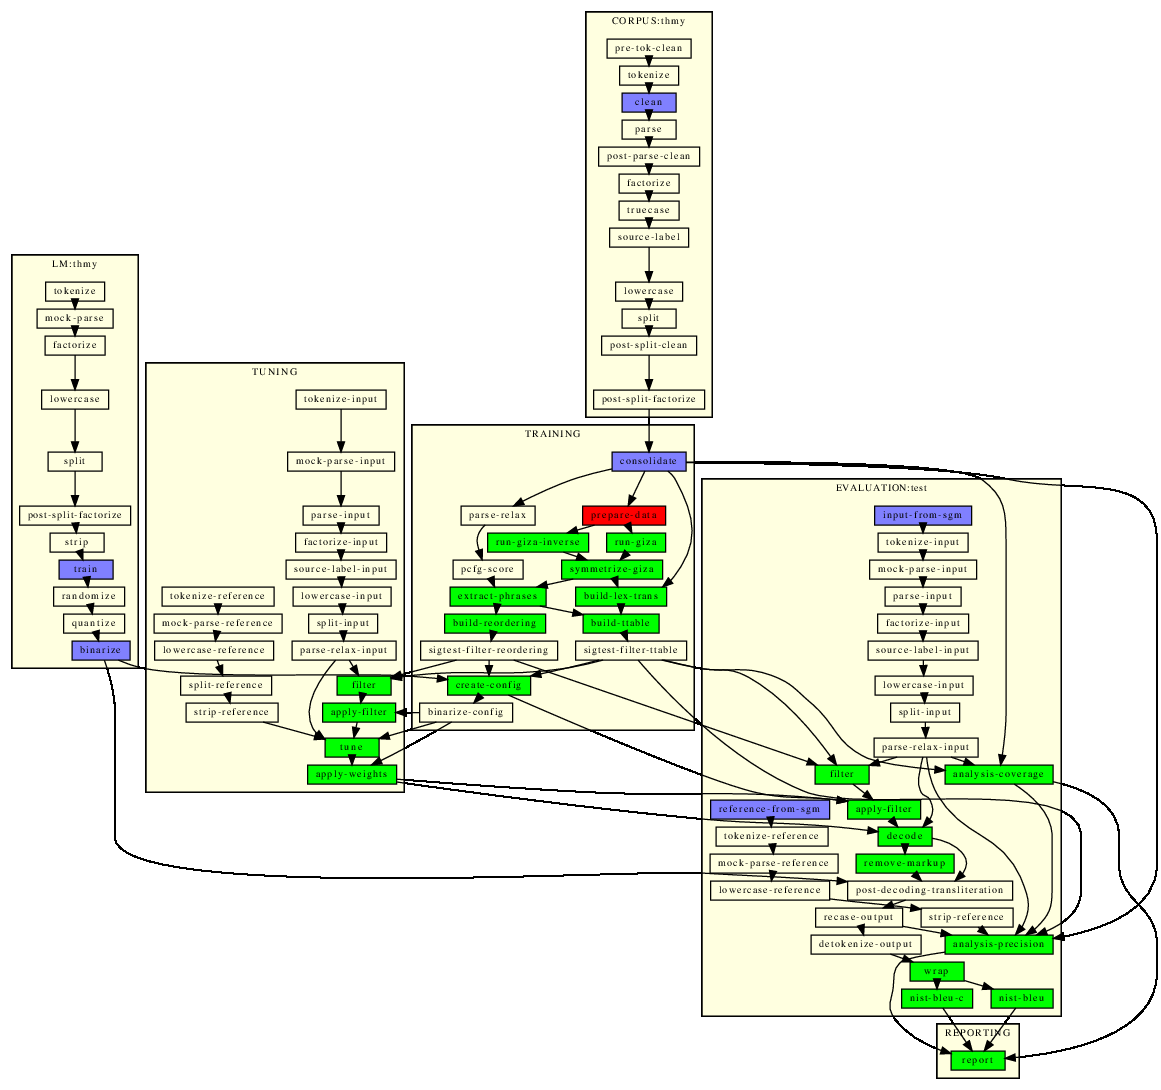

In [1]:
from IPython.display import Image
Image(filename='/home/ye/exp/SMT-NMT_tutorial/error-examples/GIZA-error.png', width=800)

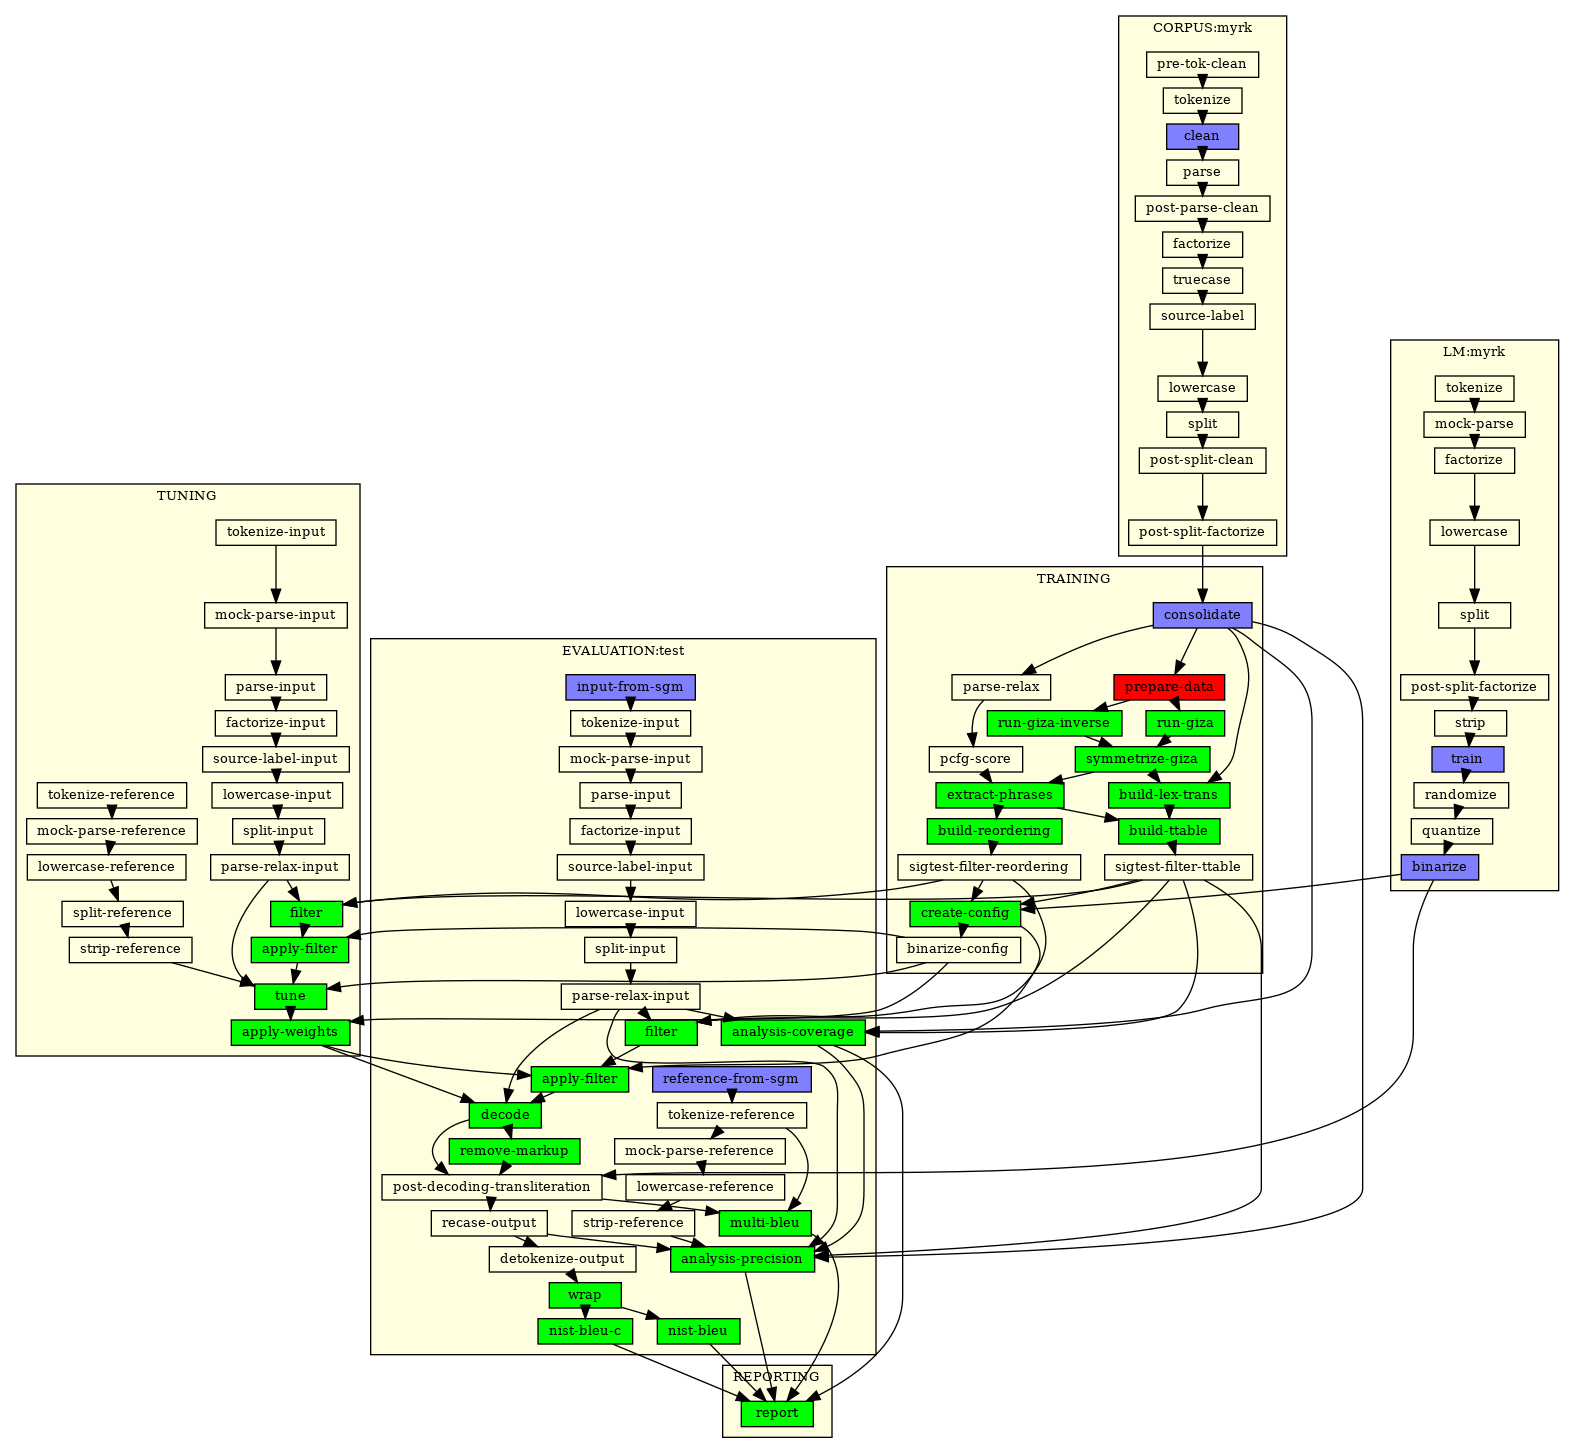

In [154]:
from IPython.display import Image
Image(filename='/home/gi/smt-work/SMT_Tutorial/pbsmt/baseline/ph-my/steps/1/graph.1.png', width=800)

## Solution

အထက်ပါ error ကိုတော့ အတွေ့အကြုံအရ သိနေတာမို့ mkcls binary ဖိုင်ကို GIZA++-v2/ ဖိုလ်ဒါအောက်ကို ကော်ပီကူးထည့်ပေးလိုက်ယုံနဲ့ ပြေလည်ပါတယ်။ အောက်ပါအတိုင်းပါ။  

ye@lst-hpc3090:~/tool/giza-pp$ cp ./mkcls-v2/mkcls ./GIZA++-v2/  

## ERROR

တချို့ error တွေက terminal မှာ ဘာမှမပြပဲ ရပ်သွားတာမျိုးလည်း ဖြစ်တတ်ပါတယ်။ အဲဒါဆိုရင် အများသောအားဖြင့် perl script မှာ path ပေးတာ လွဲသွားလို့ပါ။  

ဘာဖိုင်မှ ထွက်မလာတာကို တမင်တကာ လုပ်ပြထားတာပါ။   
config နဲ့ SMT ကို run မယ်ဆိုရင် နောက်ထပ် ပြင်ရမယ့် အဆင့် ရှိသေးတယ်။ အဲဒါက ဒေတာဖိုလ်ဒါအောက်မှာ ဝင်လုပ်ရမယ်။  

Refer following link:  
[https://github.com/ye-kyaw-thu/MTRSS/tree/master/pbsmt/data](https://github.com/ye-kyaw-thu/MTRSS/tree/master/pbsmt/data)  

ဒီတစ်ခေါက် tutorial အတွက်တော့ SMT-NMT_tutorial/pbsmt/ ဖိုလ်ဒါအောက်မှာလည်း ကောပီကူးထည့်ပေးထားမယ်။  
အဲဒီ script ကို ကိုယ့် စက်ထဲက parallel data ဒေတာ ဖိုလ်ဒါအောက်ကို ကောပီကူးယူပြီး ပြင်ဆင်ကြပါ။  

In [125]:
%cd ../../

/home/ye/exp/SMT-NMT_tutorial


In [127]:
!ls ./scripts

generate_sgms.pl  ref2sgm.pl  src2sgm.pl


In [128]:
cp -r scripts/ ./clean-data/

path ပြင်ပြီးသား update လုပ်ပြီးသား perl script တွေနဲ့ run ကြရလိမ့်မယ်။ ဥပမာ အောက်ပါအတိုင်း  

In [131]:
%cd /home/ye/exp/SMT-NMT_tutorial/clean-data/

/home/ye/exp/SMT-NMT_tutorial/clean-data


In [132]:
%cd scripts/

/home/ye/exp/SMT-NMT_tutorial/clean-data/scripts


In [134]:
!tree .

.
├── generate_sgms.pl
├── ref2sgm.pl
└── src2sgm.pl

1 directory, 3 files


In [135]:
!perl ./generate_sgms.pl

sh: 1: ./ref2sgm.pl: Permission denied
sh: 1: ./src2sgm.pl: Permission denied


**run-pbsmt.sh ကို Executable ဖြစ်အောင် permission ပေးကြရအောင်...**

In [109]:
!chmod +x ./run-pbsmt.sh

In [ ]:
%cd 

In [110]:
!cat run-pbsmt.sh

#!/bin/bash

# Written by Ye, NICT, Kyoto, Japan
# How to run: time bash ./run-pbsmt.sh 

# after running this script, you will get baseline/ folder 
perl ./generate_configs.pl

# start running PBSMT
nohup time perl ./run-baseline.pl
#perl ./run-baseline.pl


**Shell script ကို run မယ်**

In [111]:
!./run-pbsmt.sh

Can't open perl script "./generate_configs.pl": No such file or directory
nohup: ignoring input and appending output to 'nohup.out'


## Notes

ဒီ notebook မှာ ကြုံခဲ့ရသလိုပါပဲ error အများစုက path လွဲတာ၊ config ဖိုင်မှာ တခုခု update လုပ်ဖို့ ကျန်တာ၊ test data တွေကို SGM format ပြောင်းဖို့ မေ့ကျန်ခဲ့တာ၊ GIZA++ ရဲ့ mkcls ကို ရှာမတွေ့တာ တွေပါပဲ။ အဲဒီလိုမျိုး error မှ မဟုတ်ရင်တော့ ဒေတာနဲ့ ဆိုင်ပါလိမ့်မယ်။ Parallel corpus မှာ တချို့ blank line တွေ ပါနေတာတို့ special character တွေကို ရှင်းဖို့ လိုနေသေးတာတို့ ဖြစ်ဖို့ များပါတယ်။  

Error အကုန် ရှင်းပြီးရင်တော့ run လိုက်ရင် အစအဆုံး ပြီးအောင် run ပေးသွားပါလိမ့်မယ်။  

## PBSMT Experiment 

In [2]:
%pwd

'/home/ye/exp/SMT-NMT_tutorial'

In [155]:
%cd /mnt/d/Job_Requirements/PracticalProjectsFromDrYe/AIE-F/assignment-submission/class-13and14/TheinGiKyaw-Assignment/SMT_Tutorial/pbsmt/

/mnt/d/Job_Requirements/PracticalProjectsFromDrYe/AIE-F/assignment-submission/class-13and14/TheinGiKyaw-Assignment/SMT_Tutorial/pbsmt


In [156]:
!ls *

config.baseline      kc-my.config.baseline  run1.log	     run-pbsmt.sh
generate_configs.pl  nohup.out		    run-baseline.pl

data:
dev.my	dev.rk	test.my  test.rk  test-sgm  train  train.my  train.rk

steps:


In [158]:
!perl ./generate_configs.pl

In [159]:
!ls * --color=auto

config.baseline      kc-my.config.baseline  run1.log         run-pbsmt.sh
generate_configs.pl  nohup.out              run-baseline.pl

data:
dev.my  dev.rk  test.my  test.rk  test-sgm  train  train.my  train.rk

steps:


In [162]:
!tree /home/gi/smt-work/SMT_Tutorial/pbsmt/baseline

/home/gi/smt-work/SMT_Tutorial/pbsmt/baseline
├── my-ph
│   └── config.baseline.my-ph
└── ph-my
    └── config.baseline.ph-my

2 directories, 2 files


In [163]:
!time perl run-baseline.pl

my-ph-baseline /home/gi/smt-work/SMT_Tutorial/pbsmt/baseline/my-ph/config.baseline.my-ph
ph-my-baseline /home/gi/smt-work/SMT_Tutorial/pbsmt/baseline/ph-my/config.baseline.ph-my

real	1m26.701s
user	0m0.314s
sys	0m0.210s


Training data က စာကြောင်းရေ ၅၀၀၀ ကျော်၊ development data က စာကြောင်းရေ ၅၀၀ ကျော်နဲ့ test data က စာကြောင်းရေ ၁၀၀ နဲ့ပဲ run တာမို့လို့ မြန်မာ-ထိုင်း၊ ထိုင်း-မြန်မာ အတွက်က ဆာဗာပေါ်မှာ မိနစ် ၂၀ကျော်ပဲ ကြာပါတယ်။  

System တစ်ခုလုံး run သွားတဲ့ ဂရဖ်တွေကို ကြည့်ကြည့်ရအောင်။  

အောက်ပါ ဂရဖ်က မြန်မာ-ထိုင်း အတွက်ပါ။  

In [164]:
%cd /home/gi/smt-work/SMT_Tutorial/pbsmt/baseline/my-ph/steps/1

/home/gi/smt-work/SMT_Tutorial/pbsmt/baseline/my-ph/steps/1


In [165]:
!ls *

config.1
CORPUS_myrk_clean.1
CORPUS_myrk_clean.1.DONE
CORPUS_myrk_clean.1.INFO
CORPUS_myrk_clean.1.STDERR
CORPUS_myrk_clean.1.STDERR.digest
CORPUS_myrk_clean.1.STDOUT
EVALUATION_test_input-from-sgm.1
EVALUATION_test_input-from-sgm.1.DONE
EVALUATION_test_input-from-sgm.1.INFO
EVALUATION_test_input-from-sgm.1.STDERR
EVALUATION_test_input-from-sgm.1.STDERR.digest
EVALUATION_test_input-from-sgm.1.STDOUT
EVALUATION_test_reference-from-sgm.1
EVALUATION_test_reference-from-sgm.1.DONE
EVALUATION_test_reference-from-sgm.1.INFO
EVALUATION_test_reference-from-sgm.1.STDERR
EVALUATION_test_reference-from-sgm.1.STDERR.digest
EVALUATION_test_reference-from-sgm.1.STDOUT
graph.1.dot
graph.1.ps
LM_myrk_binarize.1
LM_myrk_binarize.1.DONE
LM_myrk_binarize.1.INFO
LM_myrk_binarize.1.STDERR
LM_myrk_binarize.1.STDERR.digest
LM_myrk_binarize.1.STDOUT
LM_myrk_train.1
LM_myrk_train.1.DONE
LM_myrk_train.1.INFO
LM_myrk_train.1.STDERR
LM_myrk_train.1.STDERR.digest
LM_myrk_train.1.STDOUT
parameter.1
re-use.1
running

In [166]:
!ls *.png

ls: cannot access '*.png': No such file or directory


graph.1.png ကိုပဲ quality ကောင်းအောင် ပုံပြင်ထုတ်ထားပြီး error-examples/ ဖိုလ်ဒါအောက်ထဲမှာပဲ သိမ်းထားပေးလိုက်ပါတယ်။  

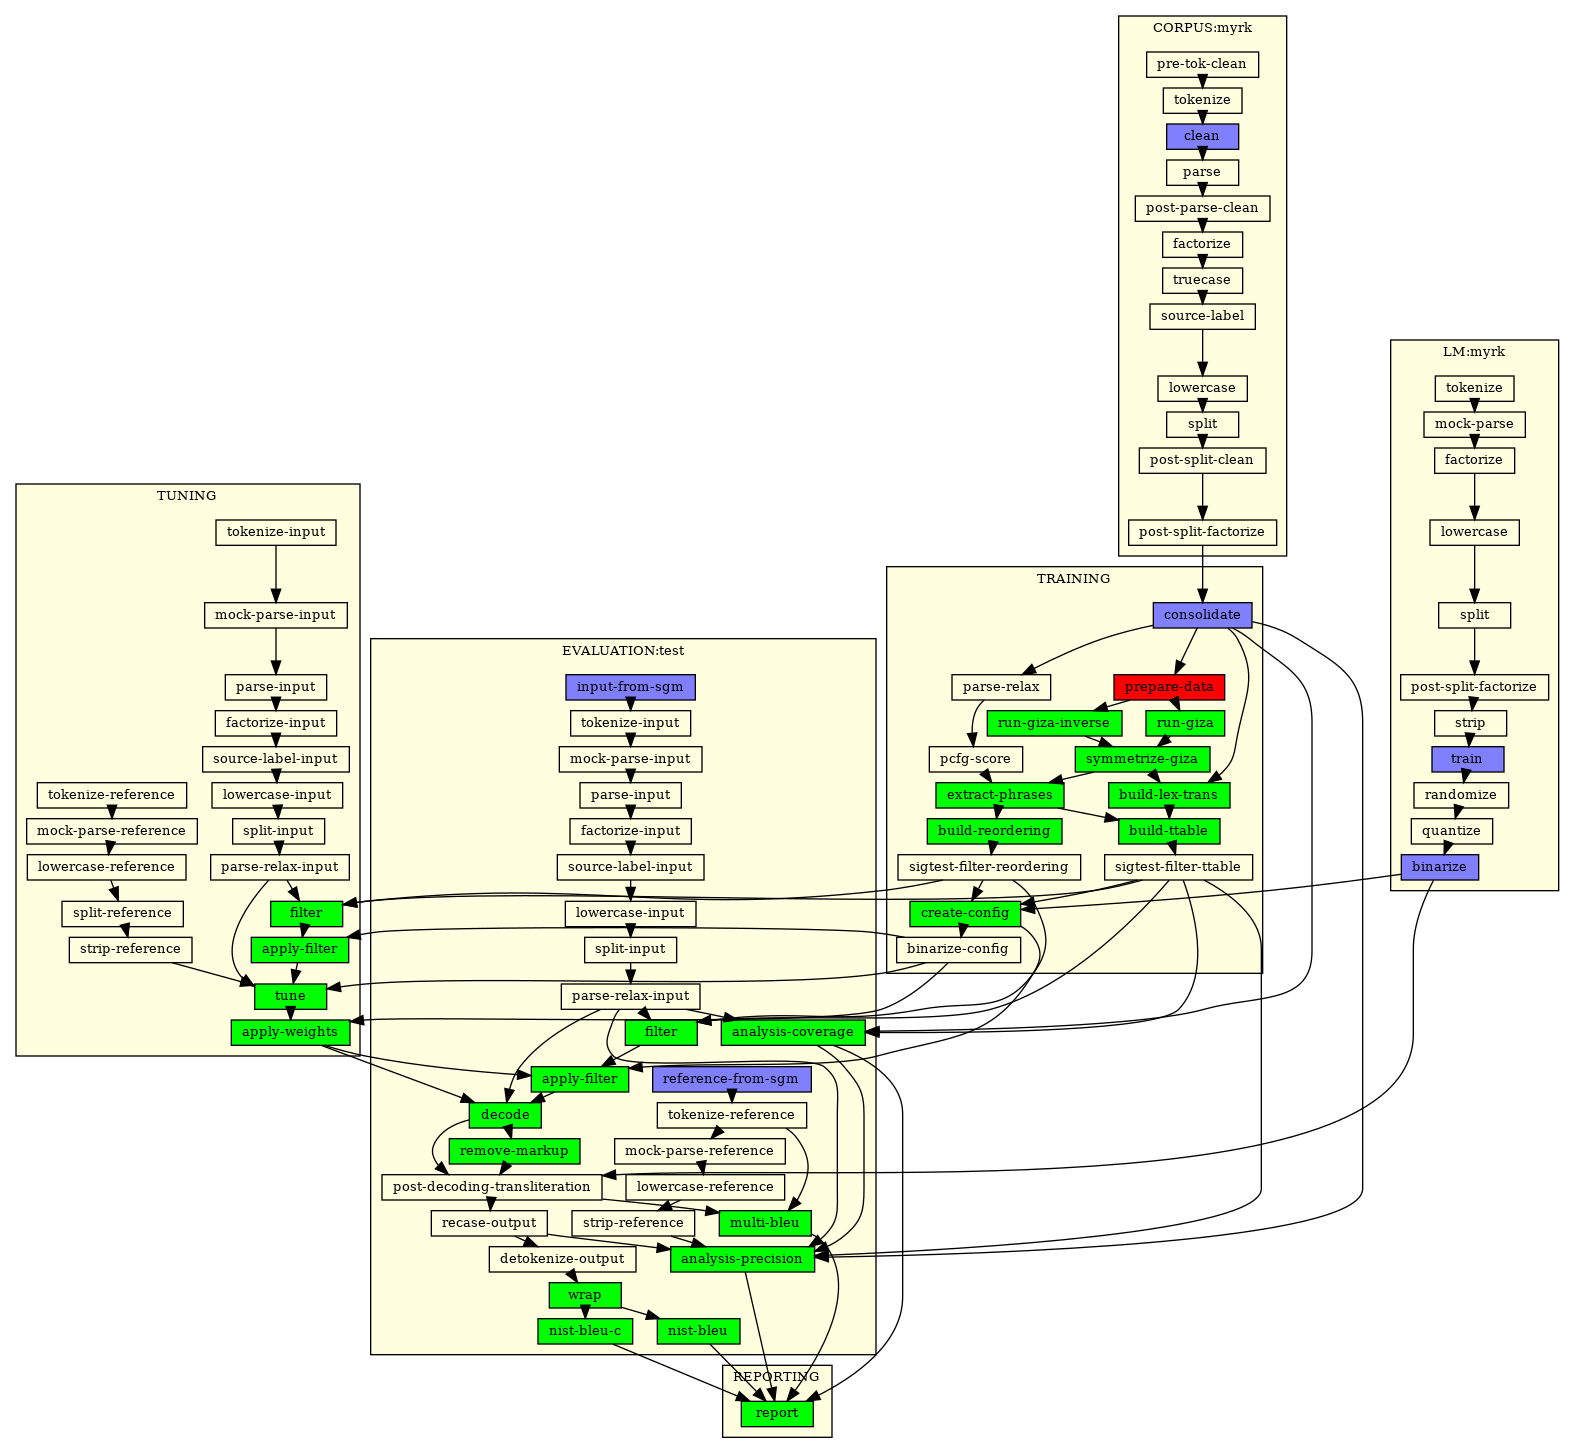

In [168]:
from IPython.display import Image
Image(filename='/home/gi/smt-work/SMT_Tutorial/pbsmt/baseline/my-ph/steps/1/graph.1.png', width=800)

အောက်ဆုံးပိုင်းမှာ အနီနဲ့ nist-bleu score နဲ့ ပတ်သက်ပြီး ပြနေပေမဲ့ စိုးရိမ်စရာ မရှိပါဘူး။ 
ဒါပေမဲ့ multi-bleu နဲ့ တွက်ထားတာကိုတော့ ဆရာတို့ လိုချင်တယ်။ အဲဒါက ပါမလာဘူး။ 
config ဖိုင်ထဲမှာ assign မလုပ်ထားလို့ ပေးနေတဲ့ error လို့ ထင်ပါတယ်။ 

Config ဖိုင် template ကို ဝင်ကြည့်တော့ အောက်ပါအတိုင်း comment ပိတ်ထားတာကို တွေ့ရတယ်။
သေချာတယ်။ ကျောင်းသားတွေကို ကိုယ်ဖာသာကိုယ် ရှာတွက်တတ်ဖို့ exercise လုပ်ဖို့ ပိတ်ထားခဲ့တာ။  

```
### BLEU
#
nist-bleu = $moses-script-dir/generic/mteval-v13a.pl
nist-bleu-c = "$moses-script-dir/generic/mteval-v13a.pl -c"
#multi-bleu = $moses-script-dir/generic/multi-bleu.perl
#ibm-bleu =
```

အထက်က multi-bleu လိုင်းကိုပါ ဖွင့်ပေးပြီး နောက်တစ်ခေါက် ထပ် run ကြည့်ရအောင်။  

In [171]:
%cd /home/gi/smt-work/SMT_Tutorial/pbsmt

/home/gi/smt-work/SMT_Tutorial/pbsmt


In [183]:
%cd /home/gi/smt-work/SMT_Tutorial/pbsmt

/home/gi/smt-work/SMT_Tutorial/pbsmt


In [184]:
%rm -r baseline/

In [193]:
%cd /mnt/d/Job_Requirements/PracticalProjectsFromDrYe/AIE-F/assignment-submission/class-13and14/TheinGiKyaw-Assignment/SMT_Tutorial/pbsmt/

/mnt/d/Job_Requirements/PracticalProjectsFromDrYe/AIE-F/assignment-submission/class-13and14/TheinGiKyaw-Assignment/SMT_Tutorial/pbsmt


In [195]:
!perl ./generate_configs.pl

In [194]:
%rm -r baseline/

In [196]:
!tree ./baseline

./baseline
├── my-ph
│   └── config.baseline.my-ph
└── ph-my
    └── config.baseline.ph-my

2 directories, 2 files


In [188]:
%cd /mnt/d/Job_Requirements/PracticalProjectsFromDrYe/AIE-F/assignment-submission/class-13and14/TheinGiKyaw-Assignment/SMT_Tutorial/pbsmt/

/mnt/d/Job_Requirements/PracticalProjectsFromDrYe/AIE-F/assignment-submission/class-13and14/TheinGiKyaw-Assignment/SMT_Tutorial/pbsmt


config ဖိုင်ကို ပြင်ပြီး နောက်တစ်ခေါက် ထပ် run မယ်။  

In [197]:
!time perl ./run-baseline.pl

my-ph-baseline /mnt/d/Job_Requirements/PracticalProjectsFromDrYe/AIE-F/assignment-submission/class-13and14/TheinGiKyaw-Assignment/SMT_Tutorial/pbsmt/baseline/my-ph/config.baseline.my-ph
ph-my-baseline /mnt/d/Job_Requirements/PracticalProjectsFromDrYe/AIE-F/assignment-submission/class-13and14/TheinGiKyaw-Assignment/SMT_Tutorial/pbsmt/baseline/ph-my/config.baseline.ph-my

real	1m23.414s
user	0m0.531s
sys	0m0.636s


test-run လုပ်ထားတဲ့ my-th ရလဒ်ကို ဝင်လေ့လာရအောင်။  

In [191]:
%cd /mnt/d/Job_Requirements/PracticalProjectsFromDrYe/AIE-F/assignment-submission/class-13and14/TheinGiKyaw-Assignment/SMT_Tutorial/pbsmt/baseline/my-ph/evaluation

/mnt/d/Job_Requirements/PracticalProjectsFromDrYe/AIE-F/assignment-submission/class-13and14/TheinGiKyaw-Assignment/SMT_Tutorial/pbsmt/baseline/my-ph/evaluation


In [198]:
!ls * --color=auto

config.baseline      kc-my.config.baseline  run1.log         run-pbsmt.sh
generate_configs.pl  nohup.out              run-baseline.pl

baseline:
my-ph  ph-my

data:
dev.my  dev.rk  test.my  test.rk  test-sgm  train  train.my  train.rk

steps:


In [199]:
!cat test.multi-bleu.1

cat: test.multi-bleu.1: No such file or directory


BLEU score က test-run လုပ်ထားတာမို့ တအားနည်းပါတယ်။ SMT pipeline အစအဆုံး ပြီးမပြီး confirm လုပ်ရအောင်။  

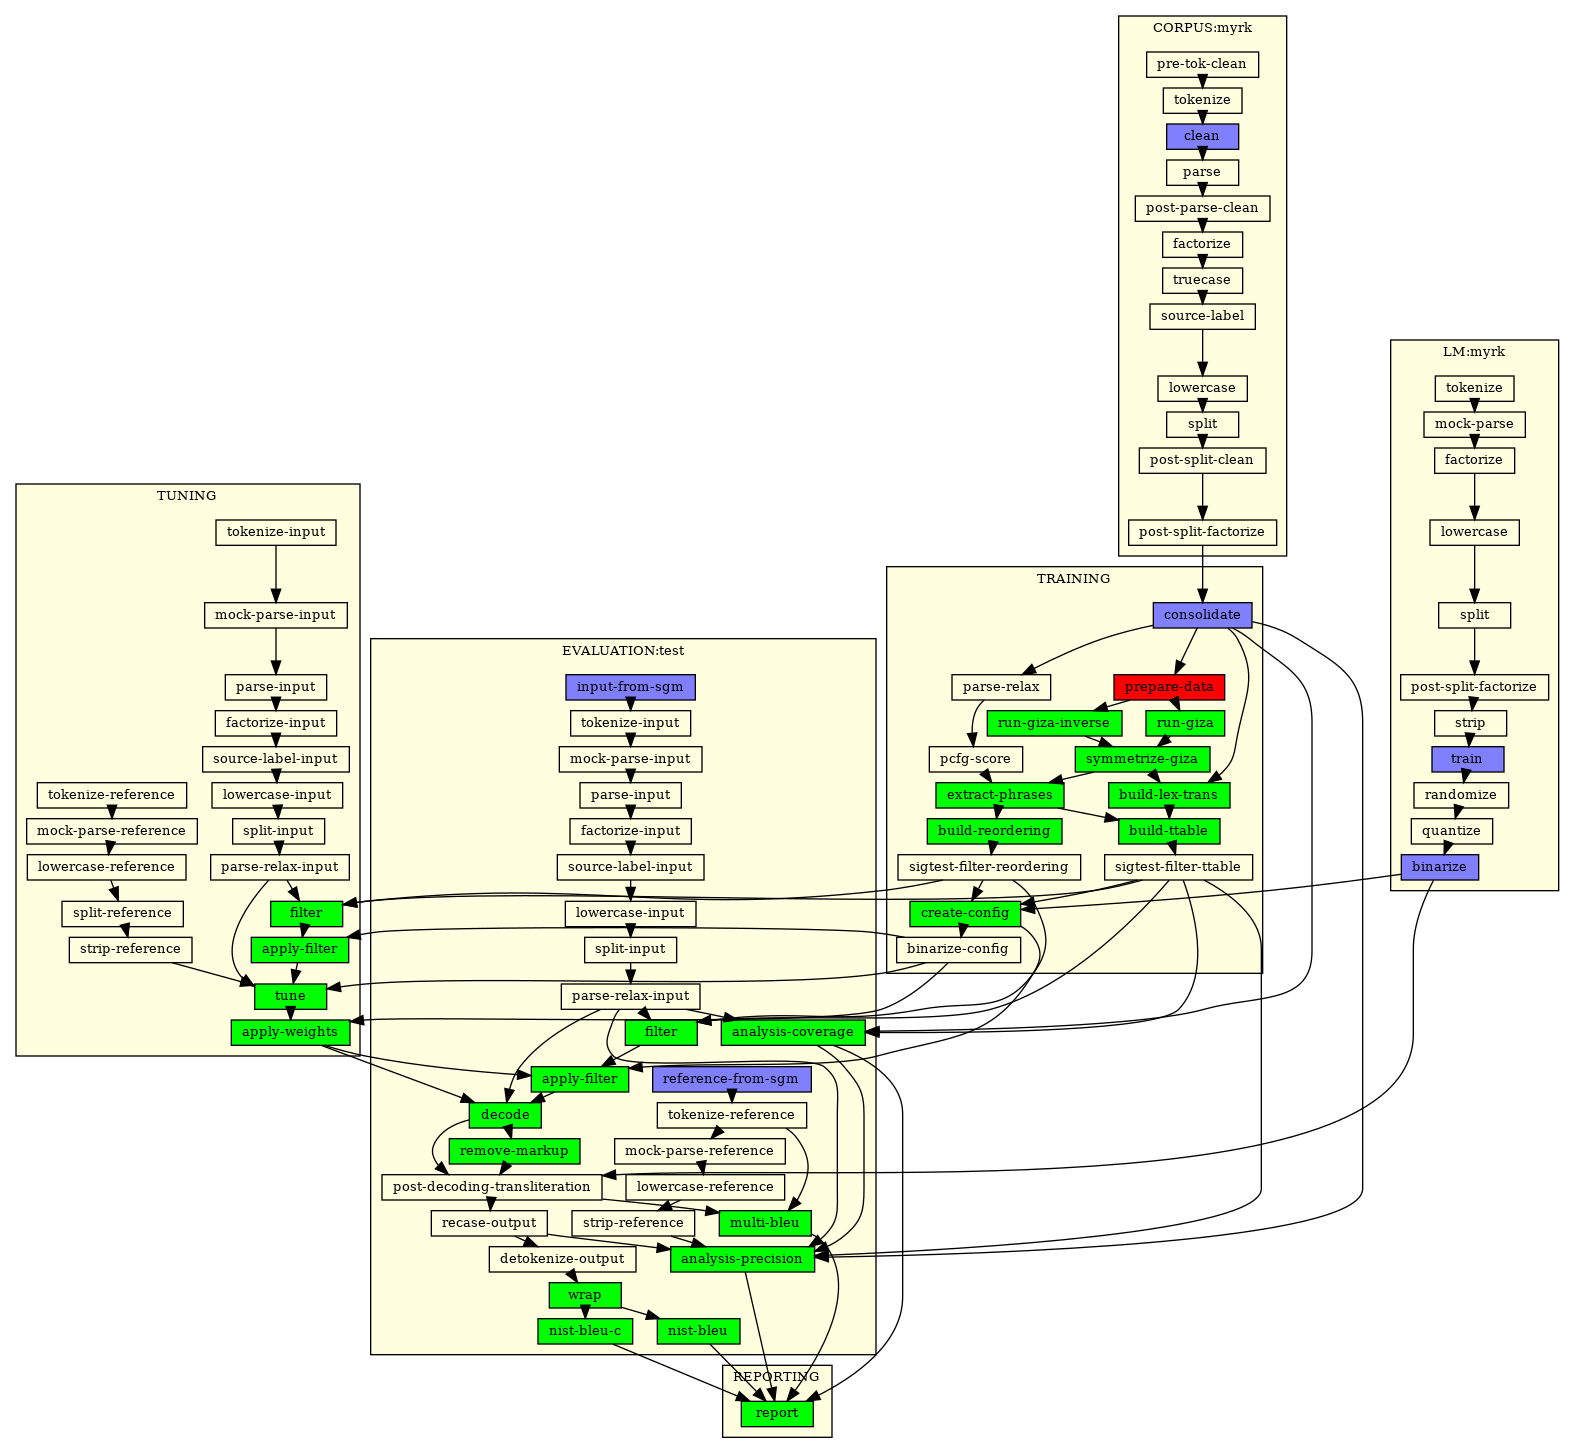

In [180]:
from IPython.display import Image
Image(filename='/home/gi/smt-work/SMT_Tutorial/pbsmt/baseline/my-ph/steps/1/graph.1.png', width=800)

အောက်ဆုံးပိုင်းမှာ multi-bleu ပါလာတာကို တွေ့ရပါပြီ။ အဲဒါကြောင့် BLEU score တွက်ပေးထားတာကို မြင်ရတာပါ။ ကောင်းပြီ။ ထိုင်း-မြန်မာ ဘက်ရဲ့ ရလဒ်ကို ဝင်ကြည့်ရအောင်။  

In [181]:
%cd /home/gi/smt-work/SMT_Tutorial/pbsmt/baseline/ph-my/evaluation

/home/gi/smt-work/SMT_Tutorial/pbsmt/baseline/ph-my/evaluation


In [182]:
!cat ./test.multi-bleu.1

cat: ./test.multi-bleu.1: No such file or directory


ထိုင်း-မြန်မာ ရလဒ်ကတော့ အထက်ပါအတိုင်းပါပဲ။ 11.77 ရရှိပါတယ်။  
test-run အစအဆုံး ပြီးပါပြီ။  

ခုလောက်ဆိုရင် SMT running pipeline တော့ အကြမ်း နားလည်ပြီလို့ ယူဆပါတယ်။  
နောက်ထပ် Jupyter notebook နှစ်ခုမှာတော့ လက်ရှိ ထိုင်းဘက်က Lab မှာ ပြင်ဆင်နေဆဲဖြစ်တဲ့ မြန်မာ-ထိုင်း medical domain parallel corpus အကုန်ကို သုံးပြီး SMT ထပ် run ပါမယ်။ 